In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/satyakidas07/employee-attendance-and-login-logout-data-bangalore/employee_attendance_bangalore_q1_2026.csv


# Employee attendance and login/logout data in bangalore: Exploratory Data Analysis

**Dataset:** `Employee-attendance-and-login-logout-data-bangalore.csv` (55,374 rows × 22 columns)
**Workflow followed:** *Exploratory Data Analysis — A Standard 23-Step Checklist for Any Dataset*
(Classroom Computer Institute — Data Analytics)

This notebook walks through **all 23 steps** of the checklist, in order, across four phases:

| Phase | Steps | Goal |
|---|---|---|
| Phase 1 — Inspect | 1–8 | Understand the shape, structure, and quality of the raw data |
| Phase 2 — Clean & Prepare | 9–16 | Organize columns, clean values, export a final clean dataset |
| Phase 3 — Analyze | 17–19 | Explore relationships and statistically test them |
| Phase 4 — Report | 20-23  | Define KPIs and charts for the final dashboard |

Each step below has its own markdown explanation followed by the code that performs it.

In [59]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RAW_PATH = "/kaggle/input/datasets/satyakidas07/employee-attendance-and-login-logout-data-bangalore/employee_attendance_bangalore_q1_2026.csv"
df = pd.read_csv(RAW_PATH)
display(df.head())

,attendance_id,employee_id,employee_name,gender,department,designation,employment_type,office_location,date_of_joining,attendance_date,shift_type,attendance_status,work_mode,login_timestamp,logout_timestamp,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours,leave_type
0,ATT0000001,VL1000,Arjun Verma,Male,Engineering,Software Engineer Intern,Intern,Koramangala HQ,2025-06-26,2026-01-02,General (09:30-18:30),Present,Work From Office,2026-01-02 09:42:03,2026-01-02 18:34:12,8.87,86,7.44,12,0,0.00,Not Applicable
1,ATT0000002,VL1001,Rekha Chatterjee,Female,Operations,Operations Manager,Full-Time,Koramangala HQ,2024-02-16,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:09:11,2026-01-02 18:25:11,9.27,67,8.15,0,6,0.00,Not Applicable
2,ATT0000003,VL1002,Tanmay Bhardwaj,Male,Operations,Operations Analyst,Full-Time,Whitefield Tech Park,2020-10-13,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:45:59,2026-01-02 20:17:31,10.53,57,9.58,15,0,0.58,Not Applicable
3,ATT0000004,VL1003,Aditya Bose,Female,Customer Success,Customer Success Executive,Full-Time,Koramangala HQ,2022-01-10,2026-01-02,Late/US Overlap (14:00-23:00),Present,Work From Office,2026-01-02 13:49:26,2026-01-02 22:24:51,8.59,76,7.32,0,36,0.00,Not Applicable
4,ATT0000005,VL1004,Uday Acharya,Male,Human Resources,Talent Acquisition Partner,Full-Time,Electronic City Campus,2024-09-09,2026-01-02,Flexible (10:30-19:30),Present,Work From Office,2026-01-02 10:51:02,2026-01-02 20:33:39,9.71,61,8.69,20,0,0.00,Not Applicable


## Phase 1 — Inspect the Raw Data (Steps 1–8)

Understand the shape, structure, and quality of the raw data.

### Step 1 — Total Number of Rows
Check the row count to understand the dataset's size (`df.shape[0]`).

In [60]:
n_rows = df.shape[0]
print(f"Total rows: {n_rows}")

Total rows: 55374


### Step 2 — Total Number of Columns
Check the column count (`df.shape[1]`).

In [61]:
n_cols = df.shape[1]
print(f"Total columns: {n_cols}")

Total columns: 22


### Step 3 — Understanding of Each Column
Go through every column and note what it represents, its expected values, and how it relates to the problem.

| Column | Represents | Expected values |
|---|---|---|
| attendance_id | Unique identifier for each daily attendance entry | `ATTxxxxxxx` (e.g., `ATT0000001` to `ATT0055374`) |
| employee_id | Unique identifier for each employee | `VLxxxx` (980 unique IDs, e.g., `VL1000` to `VL1979`) |
| employee_name | Full name of the employee | Free text (e.g., Arjun Verma, Rekha Chatterjee) |
| gender | Gender identity of the employee | Male, Female, Prefer Not to Say |
| department | Business department/unit | 10 unique departments (Engineering, Sales, Operations, Data Science, etc.) |
| designation | Job role or title | 48 unique titles (e.g., Software Engineer, Operations Analyst) |
| employment_type | Employment contract type | Full-Time, Contract, Intern, Part-Time |
| office_location | Assigned physical office campus | 5 Bangalore locations (Koramangala HQ, Whitefield Tech Park, HSR Layout Hub, Indiranagar Annexe, Electronic City Campus) |
| date_of_joining | Official employment start date | Date string format `YYYY-MM-DD` |
| attendance_date | Date of the attendance record | Date string format `YYYY-MM-DD` (57 working days in Q1 2026) |
| shift_type | Scheduled work shift and hours | 5 shift types (e.g., General (09:30-18:30), Flexible (10:30-19:30), Mid (11:00-20:00), Late/US Overlap (14:00-23:00), Early (08:00-17:00)) |
| attendance_status | Operational status for the day | Present, Half Day, On Leave |
| work_mode | Work location status | Work From Office, Work From Home, Client Site, Not Applicable (when on leave) |
| login_timestamp | System punch-in date and time | Timestamp `YYYY-MM-DD HH:MM:SS`, blank for leave days |
| logout_timestamp | System punch-out date and time | Timestamp `YYYY-MM-DD HH:MM:SS`, blank for leave days |
| total_hours_worked | Calculated gross duration between login and logout | `0.00` to `13.66` hours (`0.0` on leave days) |
| break_duration_mins | Duration spent on official breaks during shift | `0` to `135` minutes |
| net_productive_hours | Active work duration (`total_hours_worked` minus `break_duration_mins`) | `0.00` to `12.86` hours |
| late_arrival_mins | Delay in login past shift start time | `0` to `218` minutes |
| early_exit_mins | Departure time before shift end time | `0` to `391` minutes |
| overtime_hours | Hours worked beyond standard shift duration | `0.00` to `3.86` hours |
| leave_type | Classification of leave taken | Not Applicable, Sick Leave, Casual Leave, Earned Leave, Loss of Pay, Bereavement Leave, Marriage Leave, Work From Home Comp-Off, Parental Leave |

In [62]:
# Create a summary DataFrame describing structure of df
info_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),       # Data type of each column
    "n_unique": df.nunique(),             # Number of unique values per column
    "sample_value": df.iloc[0]            # First-row sample value for each column
})

# Optional: reset index to make column names a proper column
info_df = info_df.reset_index().rename(columns={"index": "column"})
info_df

,column,dtype,n_unique,sample_value
0,attendance_id,object,55374,ATT0000001
1,employee_id,object,980,VL1000
2,employee_name,object,980,Arjun Verma
3,gender,object,3,Male
4,department,object,10,Engineering
5,designation,object,48,Software Engineer Intern
6,employment_type,object,4,Intern
7,office_location,object,5,Koramangala HQ
8,date_of_joining,object,804,2025-06-26
9,attendance_date,object,57,2026-01-02


### Step 4 — Trim Extra Spaces
Strip leading/trailing whitespace from string columns and column headers — hidden spaces silently
break groupby, filtering, and joins. We first **detect** which columns are affected before fixing them
(the actual fix happens formally in Step 16, but we flag it here as required by Step 4).

In [63]:
# 1. Check for stray spaces in column names
bad_headers = [col for col in df.columns if col != col.strip()]
print("Bad headers:", bad_headers)

# 2. Check for stray spaces in text cells
for col in df.select_dtypes(include="object"):
    raw = df[col].astype(str)
    issue_count = (raw != raw.str.strip()).sum()

    if issue_count > 0:
        print(f"Column '{col}' has {issue_count} rows with extra spaces.")

Bad headers: []


### Step 5 — Remove Duplicate Elements
Identify and drop duplicate rows (`df.duplicated()`, `df.drop_duplicates()`).

In [64]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
df.loc[df.duplicated(keep=False)].sort_values("attendance_id").head(6)

Fully duplicated rows: 0


,attendance_id,employee_id,employee_name,gender,department,designation,employment_type,office_location,date_of_joining,attendance_date,shift_type,attendance_status,work_mode,login_timestamp,logout_timestamp,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours,leave_type


### Step 6 — Check Memory Size
Check memory usage (`df.memory_usage(deep=True)`) — flags if dtypes need downcasting for efficiency.

In [65]:
mem = df.memory_usage(deep=True)
print(mem)
print(f"\nTotal memory: {mem.sum() / 1024**2:.2f} MB")

Index                       132
attendance_id           3267066
employee_id             3045570
employee_name           3442982
gender                  2980742
department              3312109
designation             3830839
employment_type         3198638
office_location         3651166
date_of_joining         3267066
attendance_date         3267066
shift_type              3904830
attendance_status       3104765
work_mode               3564478
login_timestamp         3670572
logout_timestamp        3670572
total_hours_worked       442992
break_duration_mins      442992
net_productive_hours     442992
late_arrival_mins        442992
early_exit_mins          442992
overtime_hours           442992
leave_type              3483852
dtype: int64

Total memory: 54.66 MB


### Step 7 — Check Data Type of Columns
Verify each column's dtype matches what it should be (e.g., dates not stored as text, numbers not
stored as objects).

In [66]:
df.dtypes

attendance_id            object
employee_id              object
employee_name            object
gender                   object
department               object
designation              object
employment_type          object
office_location          object
date_of_joining          object
attendance_date          object
shift_type               object
attendance_status        object
work_mode                object
login_timestamp          object
logout_timestamp         object
total_hours_worked      float64
break_duration_mins       int64
net_productive_hours    float64
late_arrival_mins         int64
early_exit_mins           int64
overtime_hours          float64
leave_type               object
dtype: object

### Step 8 — Check Total Number of Null Values
Count missing values per column (`df.isnull().sum()`) to plan the cleaning strategy.

In [67]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"nulls": null_counts, "pct_missing": null_pct}).loc[null_counts > 0]

,nulls,pct_missing
logout_timestamp,2635,4.76
login_timestamp,2635,4.76


## Phase 2 — Clean & Prepare (Steps 9–16)

Organize columns, clean values, and export a final clean dataset.

### Step 9 — Cleaning ID Prefixes and Enforcing Correct Data Types
* **Issue:** `attendance_id` and `employee_id` contain static string prefixes (`ATT` and `VL`) which can be stripped or converted for cleaner indexing.
* **Resolution:** Use `str.replace()` with a try-except block to safely drop prefixes. Then, explicitly convert numeric, datetime, and categorical columns to their proper data types.

In [68]:
# 1. Strip prefixes and convert attendance_id to integer
try:
    df['attendance_id'] = df['attendance_id'].str.replace("ATT", "", regex=False).astype('int64')
    print("Successfully converted 'attendance_id' to integer.")
except Exception as e:
    print("Error converting attendance_id:", e)

# 2. Strip prefixes and convert employee_id to integer
try:
    df['employee_id'] = df['employee_id'].str.replace("VL", "", regex=False).astype('int64')
    print("Successfully converted 'employee_id' to integer.")
except Exception as e:
    print("Error converting employee_id:", e)

# Verify the data types and preview
print("\nUpdated dtypes for ID columns:")
print(df[['attendance_id', 'employee_id']].dtypes)

display(df[['attendance_id', 'employee_id']].head())

Successfully converted 'attendance_id' to integer.
Successfully converted 'employee_id' to integer.

Updated dtypes for ID columns:
attendance_id    int64
employee_id      int64
dtype: object


,attendance_id,employee_id
0,1,1000
1,2,1001
2,3,1002
3,4,1003
4,5,1004


### Step 10 — Step-by-Step Data Cleaning & Transformation

### Step A: Handling Missing Values in Timestamps (`login_timestamp` & `logout_timestamp`)
* **Issue:** There are 2,635 missing entries in login and logout timestamps.
* **Resolution:** Verify that these missing values correspond strictly to employees marked as **"On Leave"** in `attendance_status`.

In [69]:
# Verify if missing timestamps match 'On Leave' status
missing_timestamps_check = df[df['login_timestamp'].isnull()]['attendance_status'].value_counts()
print("Attendance status for rows with missing timestamps:")
print(missing_timestamps_check)

# For structural integrity, we keep them as NaN since employees on leave do not punch in/out.

Attendance status for rows with missing timestamps:
attendance_status
On Leave    2635
Name: count, dtype: int64


### Step B: Splitting Timestamps into Separate Date and Time Columns
* **Issue:** `login_timestamp` and `logout_timestamp` combine date and time strings together.
* **Resolution:** Convert them to proper pandas datetime format and split them into dedicated `login_date`, `login_time`, `logout_date`, and `logout_time` columns. *italicized text*

In [70]:
# Convert to datetime
df['login_timestamp'] = pd.to_datetime(df['login_timestamp'])
df['logout_timestamp'] = pd.to_datetime(df['logout_timestamp'])
df['attendance_date'] = pd.to_datetime(df['attendance_date']).dt.date
df['date_of_joining'] = pd.to_datetime(df['date_of_joining']).dt.date

# Split into separate Date and Time columns
df['login_date'] = df['login_timestamp'].dt.date
df['login_time'] = df['login_timestamp'].dt.time

df['logout_date'] = df['logout_timestamp'].dt.date
df['logout_time'] = df['logout_timestamp'].dt.time

# Preview split columns
display(df[['login_timestamp', 'login_date', 'login_time', 'logout_timestamp', 'logout_date', 'logout_time']].head(3))

,login_timestamp,login_date,login_time,logout_timestamp,logout_date,logout_time
0,2026-01-02 09:42:03,2026-01-02,09:42:03,2026-01-02 18:34:12,2026-01-02,18:34:12
1,2026-01-02 09:09:11,2026-01-02,09:09:11,2026-01-02 18:25:11,2026-01-02,18:25:11
2,2026-01-02 09:45:59,2026-01-02,09:45:59,2026-01-02 20:17:31,2026-01-02,20:17:31


### Step C: Recalculating Time Metrics (Gross Hours & Net Productive Hours)
* **Issue:** Simple subtraction of timestamps doesn't fully account for proper time structures, break durations, late arrivals, or early exits.
* **Resolution:** Re-calculate gross hours cleanly from timestamps, subtract `break_duration_mins` to compute correct `net_productive_hours`.

In [71]:
# Recalculate gross hours worked (in hours)
df['recalculated_gross_hours'] = (df['logout_timestamp'] - df['login_timestamp']).dt.total_seconds() / 3600.0

# Recalculate net productive hours (Gross hours minus break duration in hours)
df['recalculated_net_productive_hours'] = df['recalculated_gross_hours'] - (df['break_duration_mins'] / 60.0)

# Fill NaN for leave records
df['recalculated_gross_hours'] = df['recalculated_gross_hours'].fillna(0)
df['recalculated_net_productive_hours'] = df['recalculated_net_productive_hours'].fillna(0)

display(df[['total_hours_worked', 'recalculated_gross_hours', 'break_duration_mins', 'net_productive_hours', 'recalculated_net_productive_hours']].head())

,total_hours_worked,recalculated_gross_hours,break_duration_mins,net_productive_hours,recalculated_net_productive_hours
0,8.87,8.869167,86,7.44,7.435833
1,9.27,9.266667,67,8.15,8.150000
2,10.53,10.525556,57,9.58,9.575556
3,8.59,8.590278,76,7.32,7.323611
4,9.71,9.710278,61,8.69,8.693611


### Step 11 — Validating and Converting Column Data Types
Let's inspect columns that are currently loaded as objects (text) but should properly be **datetime**, **numeric**, or **categorical/boolean**.

In [72]:
# Define column type groups for our dataset
should_be_datetime = ["date_of_joining", "attendance_date", "login_timestamp", "logout_timestamp"]
should_be_numeric = ["total_hours_worked", "break_duration_mins", "net_productive_hours", "late_arrival_mins", "early_exit_mins", "overtime_hours"]
should_be_categorical = ["gender", "department", "designation", "employment_type", "office_location", "shift_type", "attendance_status", "work_mode", "leave_type"]

print("Currently wrong dtype (datetime expected):")
print(df[should_be_datetime].dtypes)

print("\nCurrently wrong dtype (numeric expected):")
print(df[should_be_numeric].dtypes)

print("\nCurrently wrong dtype (categorical expected):")
print(df[should_be_categorical].dtypes)

# Execute conversions
for col in should_be_datetime:
    df[col] = pd.to_datetime(df[col], errors='coerce')

for col in should_be_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in should_be_categorical:
    df[col] = df[col].astype('category')

print("\n--- All Data Types Successfully Converted ---")
print(df.dtypes)

Currently wrong dtype (datetime expected):
date_of_joining             object
attendance_date             object
login_timestamp     datetime64[ns]
logout_timestamp    datetime64[ns]
dtype: object

Currently wrong dtype (numeric expected):
total_hours_worked      float64
break_duration_mins       int64
net_productive_hours    float64
late_arrival_mins         int64
early_exit_mins           int64
overtime_hours          float64
dtype: object

Currently wrong dtype (categorical expected):
gender               object
department           object
designation          object
employment_type      object
office_location      object
shift_type           object
attendance_status    object
work_mode            object
leave_type           object
dtype: object

--- All Data Types Successfully Converted ---
attendance_id                                 int64
employee_id                                   int64
employee_name                                object
gender                                

In [73]:
# 1. Ensure main timestamps are datetime
df['login_timestamp'] = pd.to_datetime(df['login_timestamp'])
df['logout_timestamp'] = pd.to_datetime(df['logout_timestamp'])

# 2. Create proper Date and Time columns
df['login_date'] = df['login_timestamp'].dt.date
df['login_time'] = df['login_timestamp'].dt.time

df['logout_date'] = df['logout_timestamp'].dt.date
df['logout_time'] = df['logout_timestamp'].dt.time

# Optional: If you want dates stored as actual datetime objects (instead of python 'object' date types) 
# for seamless plotting or filtering, you can strip the time component like this:
df['login_date'] = pd.to_datetime(df['login_timestamp'].dt.date)
df['logout_date'] = pd.to_datetime(df['logout_timestamp'].dt.date)

# Verify updated types
print("Updated Data Types:")
print(df[['login_timestamp', 'login_date', 'login_time', 'logout_timestamp', 'logout_date', 'logout_time']].dtypes)

display(df[['login_date', 'login_time', 'logout_date', 'logout_time']].head(3))

Updated Data Types:
login_timestamp     datetime64[ns]
login_date          datetime64[ns]
login_time                  object
logout_timestamp    datetime64[ns]
logout_date         datetime64[ns]
logout_time                 object
dtype: object


,login_date,login_time,logout_date,logout_time
0,2026-01-02,09:42:03,2026-01-02,18:34:12
1,2026-01-02,09:09:11,2026-01-02,18:25:11
2,2026-01-02,09:45:59,2026-01-02,20:17:31


### Step 12 — Split Columns: Numerical vs Categorical
Separate columns into numerical and categorical groups — they need different analysis and cleaning
approaches. (Split is based on *intended* type, since several numeric columns are still stored as
text at this point.)

In [74]:
numerical_cols = [
    "total_hours_worked",
    "break_duration_mins",
    "net_productive_hours",
    "late_arrival_mins",
    "early_exit_mins",
    "overtime_hours",
]
categorical_cols = [
    "gender",
    "department",
    "designation",
    "employment_type",
    "office_location",
    "shift_type",
    "attendance_status",
    "work_mode",
    "leave_type",
]
datetime_cols = [
    "date_of_joining",
    "attendance_date",
    "login_timestamp",
    "logout_timestamp",
]
id_cols = ["attendance_id", "employee_id"]

print("Numerical:", numerical_cols)
print("\nCategorical:", categorical_cols)
print("\nDate/Time:", datetime_cols)
print("\nID columns:", id_cols)

Numerical: ['total_hours_worked', 'break_duration_mins', 'net_productive_hours', 'late_arrival_mins', 'early_exit_mins', 'overtime_hours']

Categorical: ['gender', 'department', 'designation', 'employment_type', 'office_location', 'shift_type', 'attendance_status', 'work_mode', 'leave_type']

Date/Time: ['date_of_joining', 'attendance_date', 'login_timestamp', 'logout_timestamp']

ID columns: ['attendance_id', 'employee_id']


### Step 13 — `describe()` of Numerical Columns
Run `df.describe()` on our numerical attendance metrics (`total_hours_worked`, `break_duration_mins`, `net_productive_hours`, `late_arrival_mins`, `early_exit_mins`, and `overtime_hours`) to inspect the count, mean, standard deviation, min, quartiles, and max values.

In [75]:
# Define numerical columns for the employee attendance dataset
numerical_cols = [
    "total_hours_worked",
    "break_duration_mins",
    "net_productive_hours",
    "late_arrival_mins",
    "early_exit_mins",
    "overtime_hours"
]

# Generate statistical summary
summary_stats = df[numerical_cols].describe()
display(summary_stats)

,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours
count,55374.000000,55374.000000,55374.000000,55374.000000,55374.000000,55374.000000
mean,8.724951,59.741955,7.729238,9.858471,20.099198,0.150049
std,2.413434,23.878616,2.223308,19.465159,49.630750,0.367258
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.470000,47.000000,7.370000,0.000000,0.000000,0.000000
50%,9.280000,62.000000,8.210000,0.000000,0.000000,0.000000
75%,10.000000,76.000000,8.960000,14.000000,16.000000,0.000000
max,13.660000,135.000000,12.860000,218.000000,391.000000,3.860000


### Step 14 — Write a Summary of the Dataset

**Summary:** This is a synthetic, daily attendance dataset simulating an organizational workforce operating across five major office locations in Bangalore — Koramangala HQ, Whitefield Tech Park, HSR Layout Hub, Indiranagar Annexe, and Electronic City Campus. Each of the 55,374 rows represents an individual employee's daily attendance record across Q1 2026 (spanning 57 working days), capturing employee demographics, department/designation structures, work shifts, attendance statuses, work modes, login/logout timestamps, gross and net productive hours, break durations, arrival/exit delays, overtime, and leave classifications.

**Source:** Synthetically generated for EDA-workflow and HR data analysis practice.

**Size:** 55,374 rows × 22 columns, covering 980 unique employees.

**General quality:** Deliberately structured with real-world complexities — it contains missing timestamp entries for days when employees are on leave (2,635 records), prefix-formatted ID strings (`ATT` and `VL`), combined date-time timestamp columns requiring separation, and precise operational metrics tracking shift compliance (late arrivals, early exits, breaks, and overtime).

In [76]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Office locations covered: {sorted(df['office_location'].str.strip().unique())}")
print(f"Attendance date range (raw sample): {df['attendance_date'].min()} .. {df['attendance_date'].max()}")
print(f"Attendance status breakdown:\n{df['attendance_status'].value_counts()}")

Rows: 55,374  |  Columns: 28
Office locations covered: ['Electronic City Campus', 'HSR Layout Hub', 'Indiranagar Annexe', 'Koramangala HQ', 'Whitefield Tech Park']
Attendance date range (raw sample): 2026-01-02 00:00:00 .. 2026-03-31 00:00:00
Attendance status breakdown:
attendance_status
Present     51553
On Leave     2635
Half Day     1186
Name: count, dtype: int64


### Step 15 : Standardizing Categorical Columns and Text Strings
* **Issue:** Inconsistent casing, trailing spaces, or text mismatches in columns like `department`, `designation`, `office_location`, `gender`, and `work_mode`.
* **Resolution:** Clean whitespace and standardize string formats.

In [77]:
categorical_cols = ['gender', 'department', 'designation', 'employment_type', 'office_location', 'shift_type', 'attendance_status', 'work_mode', 'leave_type']

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Specific fix for known acronyms or custom stylings if necessary
print("Unique departments after cleaning:", df['department'].unique())
print("Unique work modes after cleaning:", df['work_mode'].unique())

Unique departments after cleaning: ['Engineering' 'Operations' 'Customer Success' 'Human Resources'
 'Marketing' 'Finance' 'Sales' 'Product Management' 'Data Science'
 'Design']
Unique work modes after cleaning: ['Work From Office' 'Work From Home' 'Client Site' 'Not Applicable']


In [80]:
# Final validation checks
print(f"Total Exact Duplicates: {df.duplicated().sum()}")
print(f"Negative Work Hours Count: {(df['total_hours_worked'] < 0).sum()}")
print(f"Negative Net Productive Hours Count: {(df['net_productive_hours'] < 0).sum()}")

# Check timestamp sequence logic (excluding null/leave rows)
valid_timestamps = df.dropna(subset=['login_timestamp', 'logout_timestamp'])
invalid_logins = (pd.to_datetime(valid_timestamps['login_timestamp']) > pd.to_datetime(valid_timestamps['logout_timestamp'])).sum()
print(f"Logins occurring AFTER logouts: {invalid_logins}")

Total Exact Duplicates: 0
Negative Work Hours Count: 0
Negative Net Productive Hours Count: 0
Logins occurring AFTER logouts: 0


### Step 16 — Convert Into Final `cleaned.csv` File
Export the cleaned, prepared dataset as a single `cleaned.csv` to use as the base for all further
analysis.

In [81]:
CLEANED_PATH = "Employee-attendance-and-login-logout-data-bangalore_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset -> {CLEANED_PATH}  |  shape={df.shape}")

Saved cleaned dataset -> Employee-attendance-and-login-logout-data-bangalore_cleaned.csv  |  shape=(55374, 28)


## Phase 3 — Analyze (Steps 17–19)

Explore relationships and statistically test them.

### Step 17 — Univariate Analysis of Numerical Columns
Let's analyze the distribution of our core numerical attendance metrics using histograms with Kernel Density Estimation (KDE) curves. This will help us visualize skews, central tendencies, and spreads for metrics like working hours, breaks, late arrivals, and overtime.

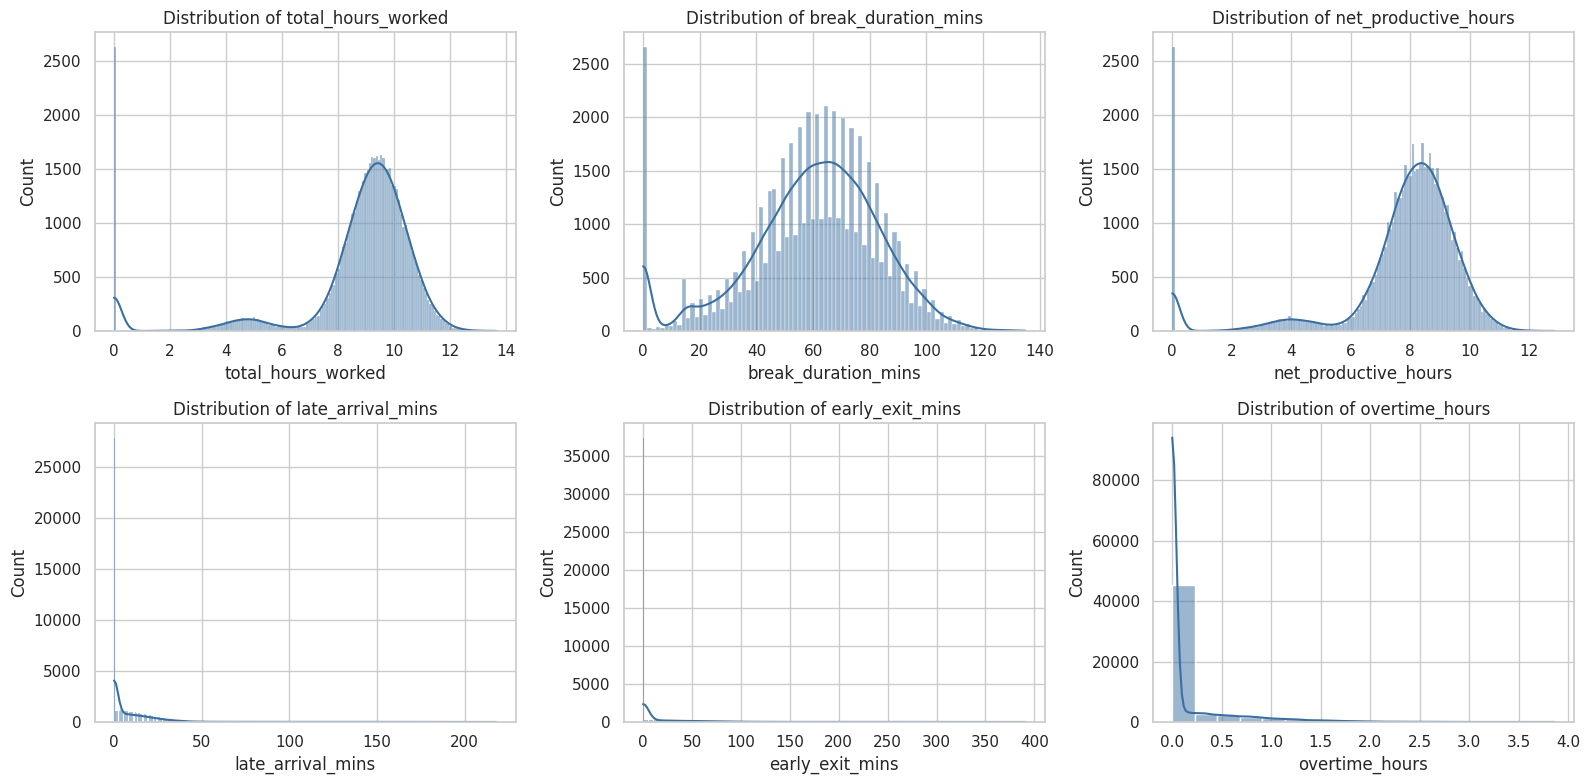

In [83]:
# Set plotting style
sns.set_theme(style="whitegrid")

# Define final numerical columns for attendance dataset
num_cols_final = [
    "total_hours_worked", 
    "break_duration_mins", 
    "net_productive_hours", 
    "late_arrival_mins", 
    "early_exit_mins", 
    "overtime_hours"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, num_cols_final):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#3b6fa0")
    ax.set_title(f"Distribution of {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Univariate Analysis of Numerical Columns (Boxplots)
Let's generate boxplots for our core numerical attendance metrics. This will help us visually identify the median, interquartile ranges (IQR), and any potential outlier values (such as extreme late arrivals or long break durations).

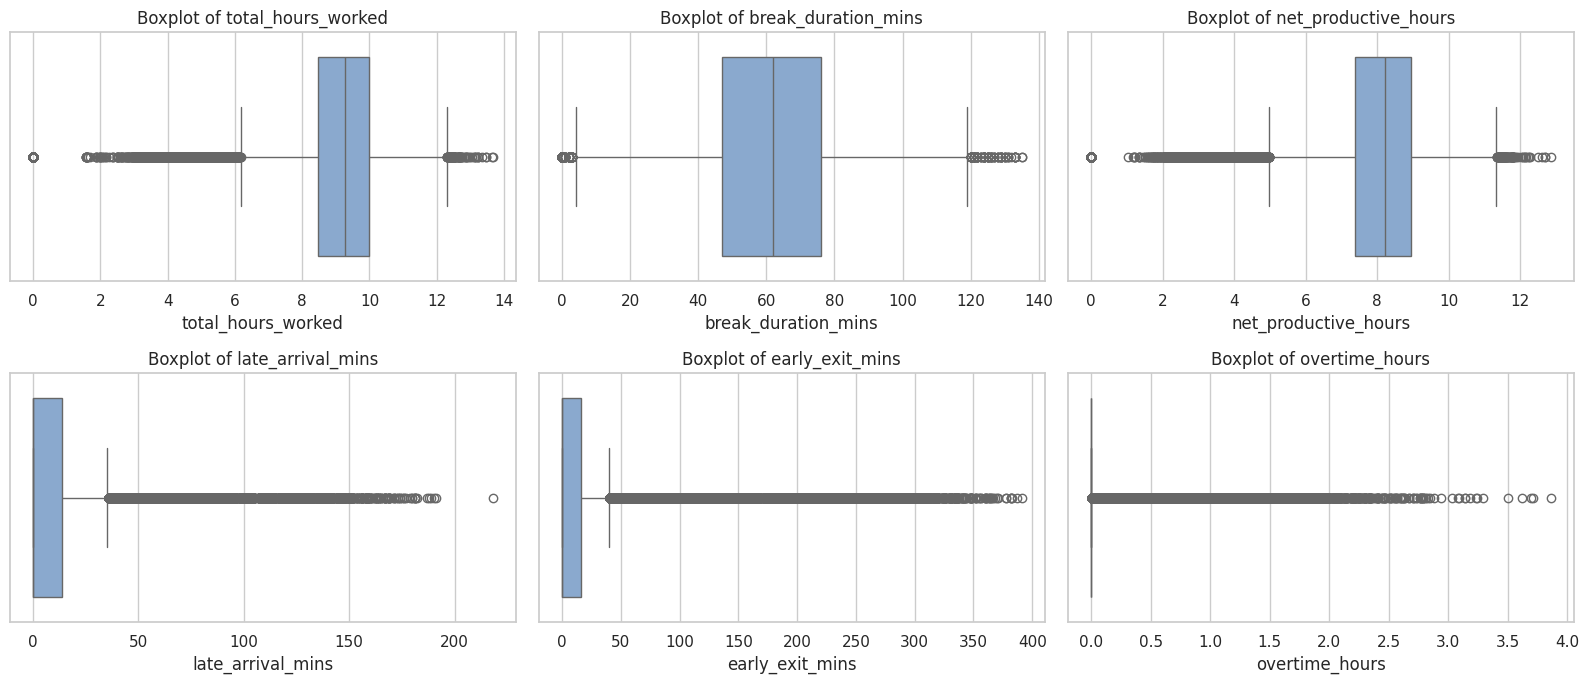

In [84]:
# Set style
sns.set_theme(style="whitegrid")

# Define numerical columns for attendance dataset
num_cols_final = [
    "total_hours_worked", 
    "break_duration_mins", 
    "net_productive_hours", 
    "late_arrival_mins", 
    "early_exit_mins", 
    "overtime_hours"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols_final):
    sns.boxplot(x=df[c], ax=ax, color="#7fa8d9")
    ax.set_title(f"Boxplot of {c}")
    ax.set_xlabel(c)

plt.tight_layout()
plt.show()

### Advanced Numerical Summary Statistics
Let's compute a detailed aggregate summary of our numerical attendance metrics using `agg()`. This includes the **mean**, **median**, **standard deviation**, **mode**, **skewness**, and **kurtosis** to understand the distribution shapes and central tendencies of our data.

In [85]:
# Define final numerical columns
num_cols_final = [
    "total_hours_worked", 
    "break_duration_mins", 
    "net_productive_hours", 
    "late_arrival_mins", 
    "early_exit_mins", 
    "overtime_hours"
]

# Calculate custom aggregate statistics
summary_stats = df[num_cols_final].agg([
    "mean", 
    "median", 
    "std", 
    lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan, 
    "skew", 
    "kurt"
])

# Rename index for clarity
summary_stats.index = ["mean", "median", "std", "mode", "skew", "kurtosis"]

# Display formatted results
display(summary_stats.round(2))

,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours
mean,8.72,59.74,7.73,9.86,20.10,0.15
median,9.28,62.00,8.21,0.00,0.00,0.00
std,2.41,23.88,2.22,19.47,49.63,0.37
mode,0.00,0.00,0.00,0.00,0.00,0.00
skew,-2.38,-0.56,-2.12,4.20,3.78,3.09
kurtosis,5.81,0.35,4.77,22.95,16.00,10.85


### Univariate Analysis of Categorical Columns
Let's analyze the distribution of key categorical variables using count plots and a pie chart. Specifically, we will look at attendance volume across **Office Locations**, **Departments**, and the overall split for **Attendance Status** (Present, On Leave, Half Day).

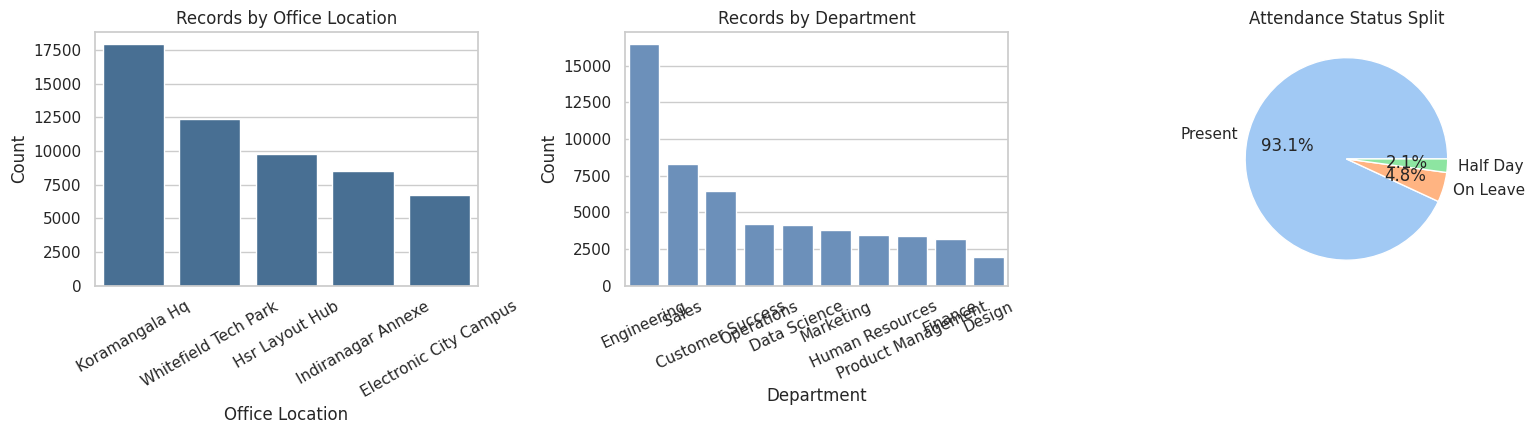

In [86]:
# Set style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Countplot for Office Location
sns.countplot(
    data=df, 
    x="office_location", 
    order=df["office_location"].value_counts().index, 
    ax=axes[0], 
    color="#3b6fa0"
)
axes[0].set_title("Records by Office Location")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("Office Location")
axes[0].set_ylabel("Count")

# 2. Countplot for Department
sns.countplot(
    data=df, 
    x="department", 
    order=df["department"].value_counts().index, 
    ax=axes[1], 
    color="#5f8fc7"
)
axes[1].set_title("Records by Department")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Count")

# 3. Pie chart for Attendance Status Split
df["attendance_status"].value_counts().plot.pie(
    autopct="%1.1f%%", 
    ax=axes[2], 
    ylabel="", 
    colors=sns.color_palette("pastel")
)
axes[2].set_title("Attendance Status Split")

plt.tight_layout()
plt.show()

### Step 17 — Bivariate Analysis (Numerical vs. Numerical)
Let's analyze the relationship between two numerical variables using a scatter plot and calculate the Pearson correlation coefficient. Specifically, we will look at **`total_hours_worked`** versus **`net_productive_hours`** to see how closely gross hours track with active productivity.

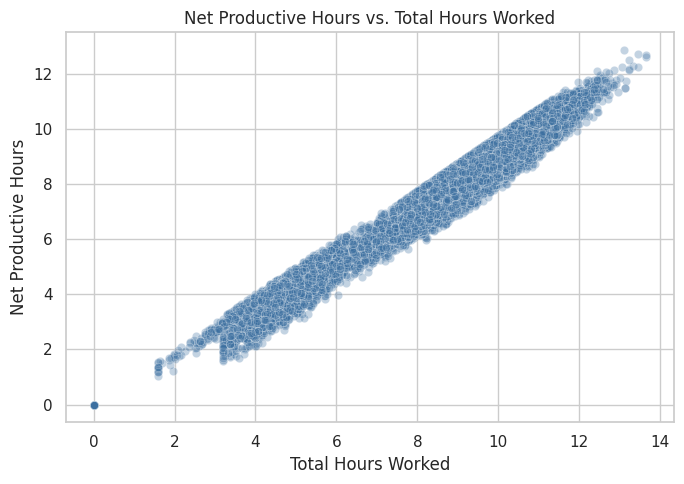

Pearson r = 0.989  (p = 0.00e+00)


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_theme(style="whitegrid")

# Create scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df, 
    x="total_hours_worked", 
    y="net_productive_hours", 
    alpha=0.3, 
    ax=ax, 
    color="#3b6fa0"
)
ax.set_title("Net Productive Hours vs. Total Hours Worked")
ax.set_xlabel("Total Hours Worked")
ax.set_ylabel("Net Productive Hours")
plt.tight_layout()
plt.show()

# Calculate Pearson correlation coefficient and p-value
pearson_r, pearson_p = stats.pearsonr(df["total_hours_worked"], df["net_productive_hours"])
print(f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2e})")

### Bivariate Analysis (Numerical vs. Categorical)
Let's analyze how a numerical metric varies across categorical groups using boxplots. Specifically, we will look at **`net_productive_hours`** broken down by **`department`** to evaluate how productivity levels compare across different teams.

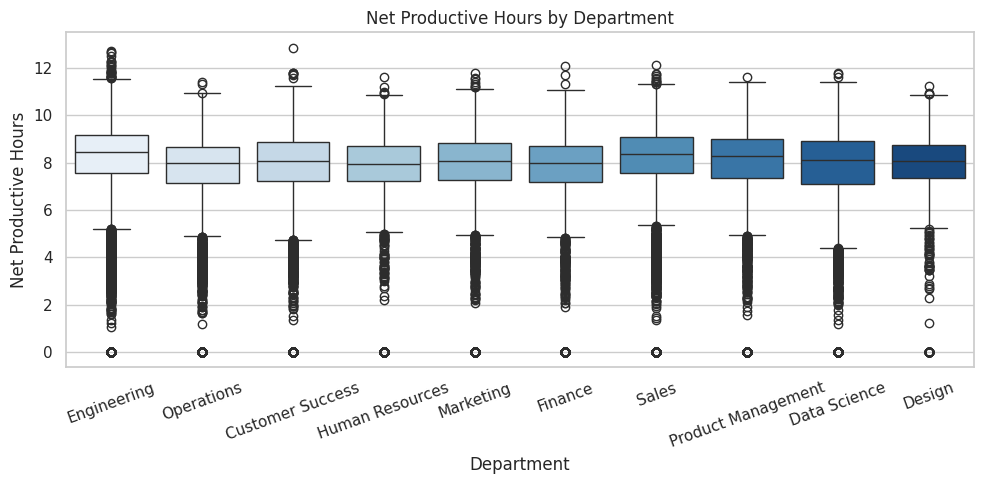

In [88]:
# Set style
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Create boxplot of net productive hours by department
sns.boxplot(
    data=df, 
    x="department", 
    y="net_productive_hours", 
    hue="department", 
    palette="Blues", 
    ax=ax
)

# Remove redundant legend if present
if ax.legend_ is not None:
    ax.legend().remove()

ax.set_title("Net Productive Hours by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Net Productive Hours")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Bivariate Analysis (Aggregated Bar Plot)
Let's analyze the average performance across categorical groups using a horizontal bar plot. We will sort the categories by their mean values to clearly visualize which departments achieve the highest average **`net_productive_hours`**.

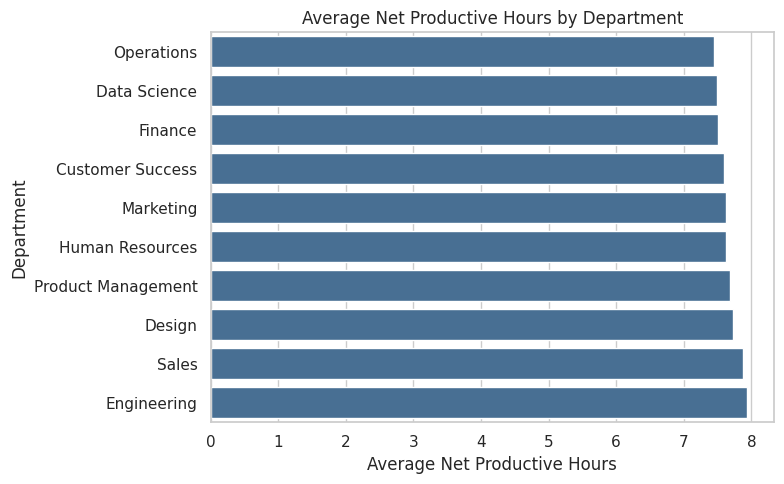

In [89]:
# Set style
sns.set_theme(style="whitegrid")

# Sort departments by mean net_productive_hours first
order = df.groupby("department")["net_productive_hours"].mean().sort_values().index

fig, ax = plt.subplots(figsize=(8, 5))

# Seaborn automatically calculates the mean net productive hours per department
sns.barplot(
    data=df, 
    y="department", 
    x="net_productive_hours", 
    order=order, 
    color="#3b6fa0", 
    errorbar=None, 
    ax=ax
)

ax.set_title("Average Net Productive Hours by Department")
ax.set_xlabel("Average Net Productive Hours")
ax.set_ylabel("Department")
plt.tight_layout()
plt.show()

### Bivariate Analysis (Categorical vs. Categorical Cross-Tabulation)
Let's analyze the proportion of categorical outcomes across groups using a normalized cross-tabulation and a stacked bar chart. Specifically, we will examine the percentage composition of **`attendance_status`** across different **`office_location`**s.

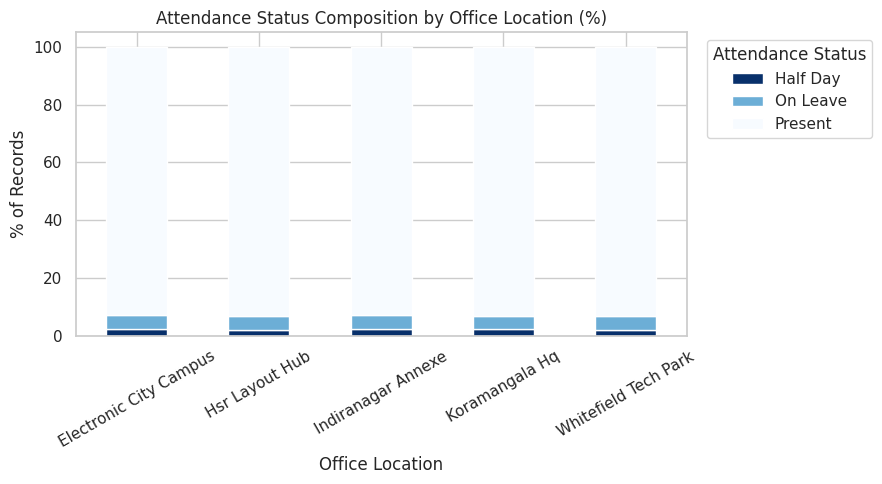

attendance_status,Half Day,On Leave,Present
office_location,,,
Electronic City Campus,2.1,4.9,93.0
Hsr Layout Hub,2.1,4.8,93.1
Indiranagar Annexe,2.2,4.7,93.1
Koramangala Hq,2.2,4.7,93.1
Whitefield Tech Park,2.0,4.8,93.1


In [90]:
# Set style
sns.set_theme(style="whitegrid")

# Create normalized cross-tabulation (percentages by row)
ct = pd.crosstab(df["office_location"], df["attendance_status"], normalize="index") * 100

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Blues_r", ax=ax)

ax.set_title("Attendance Status Composition by Office Location (%)")
ax.set_ylabel("% of Records")
ax.set_xlabel("Office Location")
plt.xticks(rotation=30)
plt.legend(title="Attendance Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Display rounded numeric breakdown table
display(ct.round(1))

### Step 18 — Multivariate Analysis (Pairplot)
Let's analyze pairwise relationships and joint distributions across our key numerical attendance metrics using a Seaborn pairplot. To keep the plot clean and readable, we will take a random sample of 600 rows from our dataset.

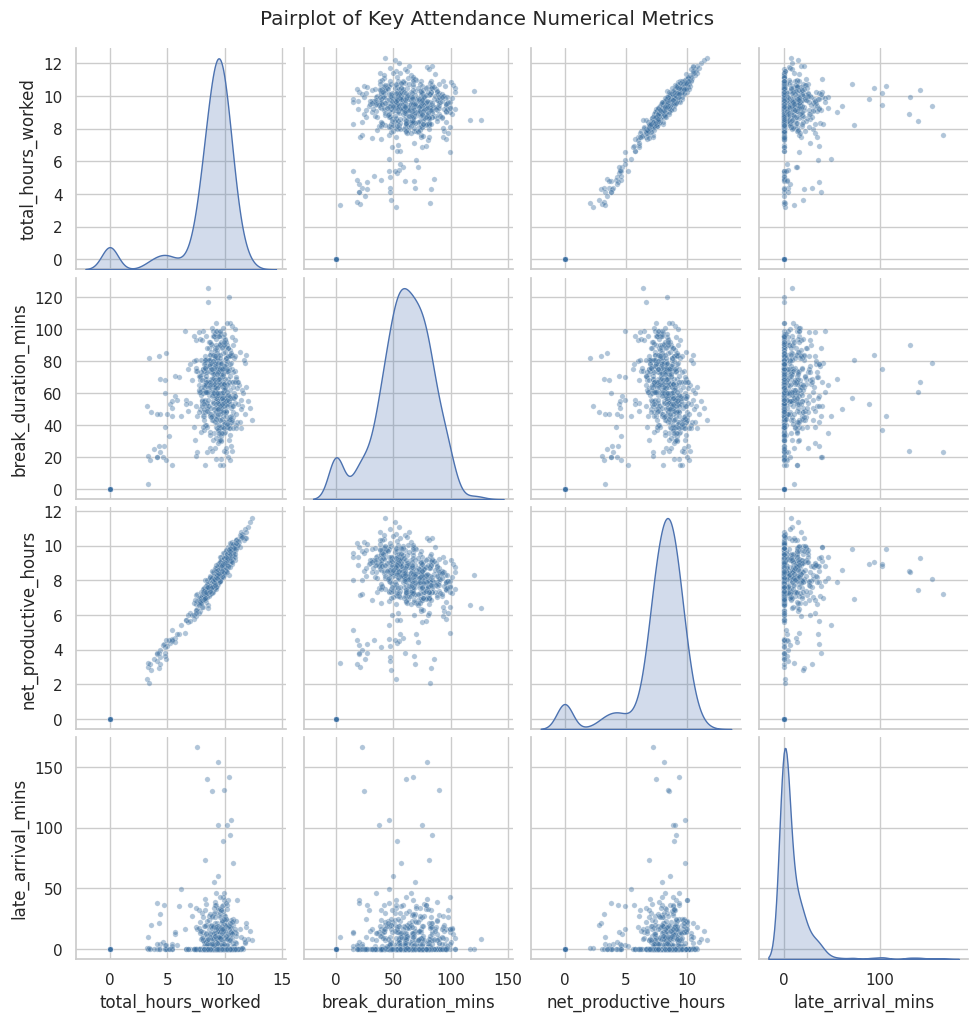

In [91]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Define key numerical columns and take a random sample
cols = ["total_hours_worked", "break_duration_mins", "net_productive_hours", "late_arrival_mins"]
sample_df = df[cols].dropna().sample(n=min(600, len(df)), random_state=42)

# 2. Plot pairplot with KDE diagonal
g = sns.pairplot(
    sample_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15, "color": "#3b6fa0"}
)

plt.suptitle("Pairplot of Key Attendance Numerical Metrics", y=1.02)
plt.show()

### Multivariate Analysis (Correlation Heatmap)
Let's compute the correlation matrix across our final numerical attendance features and visualize it using a Seaborn heatmap with annotated correlation coefficients. This will help us identify strong linear relationships (such as between gross hours and net productive hours) across our workforce metrics.

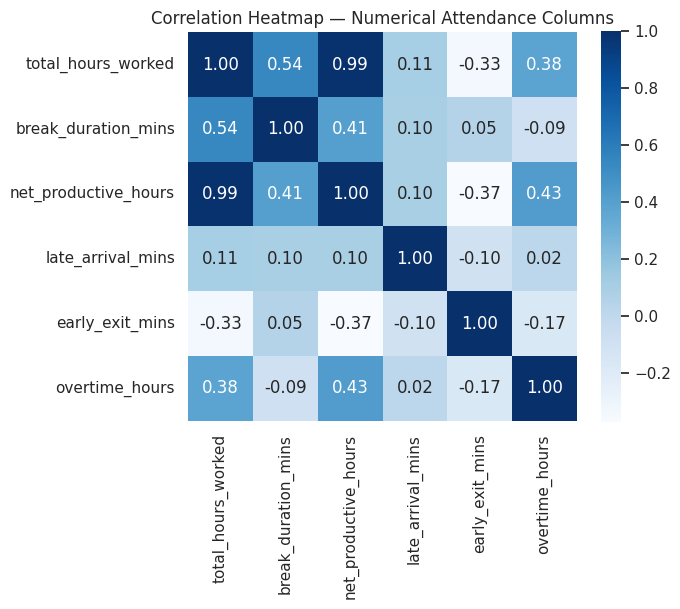

In [92]:
# Set style
sns.set_theme(style="whitegrid")

# Define final numerical columns
num_cols_final = [
    "total_hours_worked", 
    "break_duration_mins", 
    "net_productive_hours", 
    "late_arrival_mins", 
    "early_exit_mins", 
    "overtime_hours"
]

# Calculate correlation matrix
corr = df[num_cols_final].corr(numeric_only=True)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    cbar=True,
    square=True,
    ax=ax
)

ax.set_title("Correlation Heatmap — Numerical Attendance Columns")
plt.tight_layout()
plt.show()

### Multivariate Analysis (Grouped Box Plots)
Let's analyze how a numerical metric varies across two categorical dimensions simultaneously using a grouped box plot with a `hue` parameter. Specifically, we will examine **`net_productive_hours`** across different **`office_location`**s, grouped and colored by **`employment_type`**.

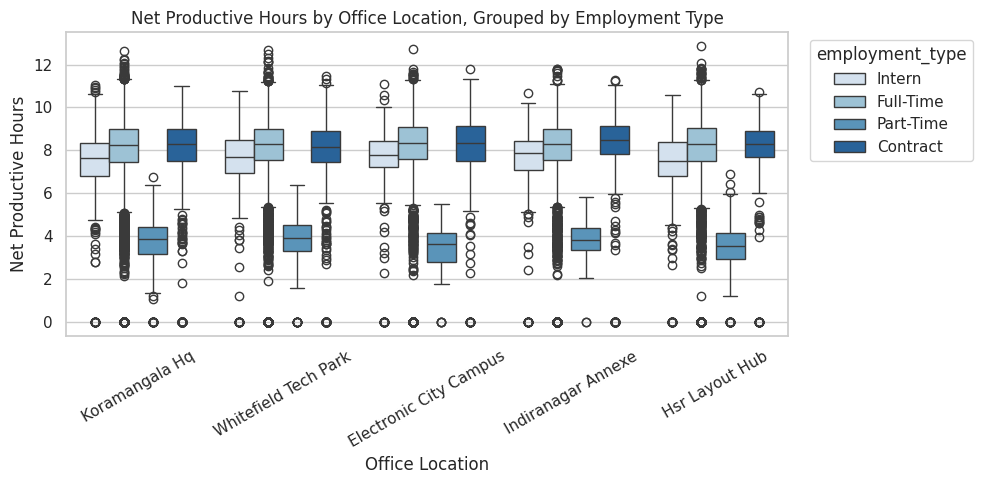

In [93]:
# Set style
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Create grouped box plot
sns.boxplot(
    data=df, 
    x="office_location", 
    y="net_productive_hours", 
    hue="employment_type", 
    palette="Blues", 
    ax=ax
)

ax.set_title("Net Productive Hours by Office Location, Grouped by Employment Type")
ax.set_xlabel("Office Location")
ax.set_ylabel("Net Productive Hours")
ax.tick_params(axis="x", rotation=30)

# Move legend outside the plot box cleanly
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Multivariate Analysis (FacetGrid Distribution)
Let's analyze how a numerical metric's distribution varies across different subsets of our data using a Seaborn `FacetGrid`. Specifically, we will examine the distribution of **`late_arrival_mins`** split across each **`office_location`** campus.

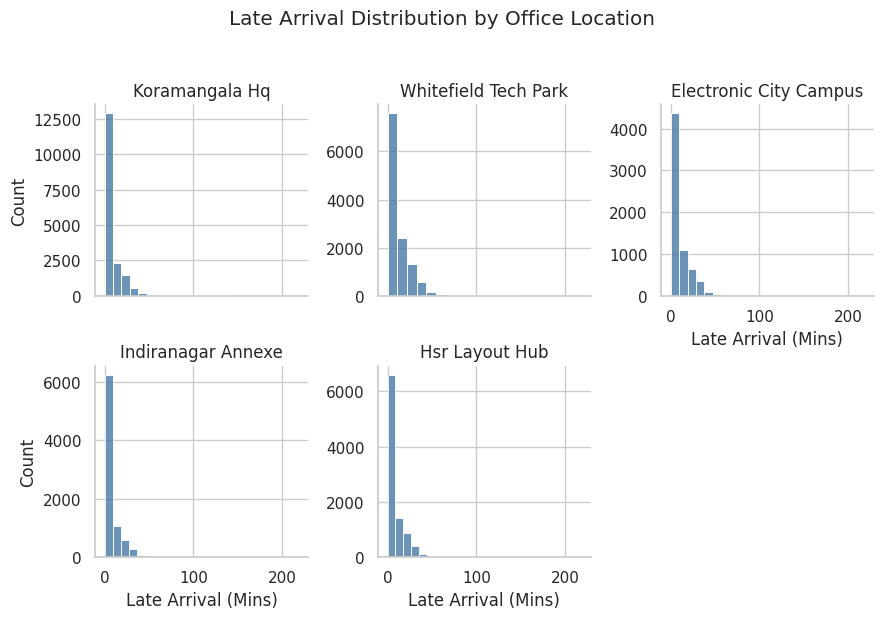

In [94]:
# Set style
sns.set_theme(style="whitegrid")

# Create FacetGrid split by office location
g = sns.FacetGrid(df, col="office_location", col_wrap=3, height=3, sharey=False)
g.map_dataframe(sns.histplot, x="late_arrival_mins", color="#3b6fa0", bins=20)
g.set_titles("{col_name}")
g.set_axis_labels("Late Arrival (Mins)", "Count")
g.fig.suptitle("Late Arrival Distribution by Office Location", y=1.03)

plt.tight_layout()
plt.show()

### Step 19 — Hypothesis Testing
Let's conduct a formal hypothesis test to compare employee productivity across different work modes. 
* **Null Hypothesis ($H_0$):** There is no significant difference in `net_productive_hours` between employees working from the office vs. working from home.
* **Alternative Hypothesis ($H_1$):** There is a significant difference in `net_productive_hours` between the two work modes.

Before choosing our test (Student's t-test vs. Mann-Whitney U test), we will check for normality using the Shapiro-Wilk test (on a sampled subset since our dataset is large) and equal variance using Levene's test.

In [97]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Filter groups for comparison
wfo = df[df['work_mode'] == 'Work From Office']['net_productive_hours'].dropna()
wfh = df[df['work_mode'] == 'Work From Home']['net_productive_hours'].dropna()

# 2. Check Normality using Shapiro-Wilk test (sampled due to large N)
sample_n = min(500, len(wfo))
shapiro_wfo = stats.shapiro(wfo.sample(n=sample_n, random_state=42))
shapiro_wfh = stats.shapiro(wfh.sample(n=sample_n, random_state=42))

print(f"Shapiro-Wilk Normality Test (WFO) p-value: {shapiro_wfo.pvalue:.5f}")
print(f"Shapiro-Wilk Normality Test (WFH) p-value: {shapiro_wfh.pvalue:.5f}")

# 3. Check Equal Variance using Levene's Test
levene_res = stats.levene(wfo, wfh)
print(f"Levene's Test for Equal Variance p-value: {levene_res.pvalue:.5f}")

# 4. Perform Independent t-test (or Mann-Whitney U if non-normal)
# Given large sample sizes, parametric t-test is robust, but let's run Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(wfo, wfh, equal_var=False)
print(f"\nWelch's t-test Results:")
print(f"t-statistic = {t_stat:.3f} | p-value = {p_val:.3e}")

if p_val < 0.05:
    print("Conclusion: Reject H₀ — There is a statistically significant difference in net productive hours between Work From Office and Work From Home.")
else:
    print("Conclusion: Fail to reject H₀ — No statistically significant difference found.")

Shapiro-Wilk Normality Test (WFO) p-value: 0.00000
Shapiro-Wilk Normality Test (WFH) p-value: 0.00000
Levene's Test for Equal Variance p-value: 0.28424

Welch's t-test Results:
t-statistic = -4.366 | p-value = 1.270e-05
Conclusion: Reject H₀ — There is a statistically significant difference in net productive hours between Work From Office and Work From Home.


### Step 19a — Numerical vs. Numerical Hypothesis Testing (Pearson Correlation)
Let's test the linear relationship between two continuous numerical variables using a Pearson correlation test.
* **$H_0$:** There is no linear correlation between total hours worked and net productive hours.
* **$H_1$:** There is a linear correlation between total hours worked and net productive hours.

In [96]:
from scipy import stats

# 1. Extract clean numeric series
x = df['total_hours_worked'].dropna()
y = df['net_productive_hours'].dropna()

# 2. Run Pearson correlation test
r_val, p_val = stats.pearsonr(x, y)

print(f"Pearson Correlation Coefficient (r) = {r_val:.4f}")
print(f"p-value = {p_val:.4e}")

# 3. Conclusion check
alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject H₀ — There is a statistically significant linear correlation between total hours worked and net productive hours.")
else:
    print("\nConclusion: Fail to reject H₀ — No significant linear correlation found.")

Pearson Correlation Coefficient (r) = 0.9886
p-value = 0.0000e+00

Conclusion: Reject H₀ — There is a statistically significant linear correlation between total hours worked and net productive hours.


### Step 19b — Numerical vs. Categorical Hypothesis Testing (Two-Sample t-test)
Let's conduct an independent two-sample t-test (Welch's t-test) to compare late arrivals between employees working from the office versus working from home.
* **$H_0$:** The mean late arrival minutes are the same for office-based and home-based work modes.
* **$H_1$:** The mean late arrival minutes differ between the two work modes.

In [99]:
# 1. Filter numerical metric for two specific categorical groups
group1 = df[df['work_mode'] == 'Work From Office']['late_arrival_mins'].dropna()
group2 = df[df['work_mode'] == 'Work From Home']['late_arrival_mins'].dropna()

# 2. Run independent two-sample t-test (Welch's t-test for unequal variance robustness)
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

print(f"Welch's t-test Results:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_val:.4e}")

# 3. Conclusion check
alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject H₀ — There is a statistically significant difference in mean late arrival minutes between Work From Office and Work From Home.")
else:
    print("\nConclusion: Fail to reject H₀ — No significant difference found.")

Welch's t-test Results:
t-statistic = 28.254
p-value = 2.8055e-172

Conclusion: Reject H₀ — There is a statistically significant difference in mean late arrival minutes between Work From Office and Work From Home.


### Step 19c — Numerical vs. Categorical Hypothesis Testing (One-Way ANOVA)
Let's conduct a one-way ANOVA test to determine if there are statistically significant differences in mean productivity (`net_productive_hours`) across multiple departments (10 unique groups).
* **$H_0$:** The mean net productive hours are the same across all departments.
* **$H_1$:** At least one department has a significantly different mean net productive hour.

In [101]:
# 1. Group net productive hours by shift type
grouped = [group["net_productive_hours"].dropna() for _, group in df.groupby("shift_type")]

# 2. Check variance (Levene's test) and run One-Way ANOVA
_, levene_p = stats.levene(*grouped)
f_stat, p_val = stats.f_oneway(*grouped)

# 3. Print results and checks
print(f"Levene's Test p-val: {levene_p:.4f}")
print(f"ANOVA F-stat: {f_stat:.2f}, p-val: {p_val:.2e}")

if p_val < 0.05:
    print("Result: Reject H₀ — Significant difference in net productive hours across shift types.")
else:
    print("Result: Fail to reject H₀ — No significant difference across shift types.")

# 4. Display average net productive hours per shift type
print("\nAverage Net Productive Hours per Shift Type:")
display(df.groupby("shift_type")["net_productive_hours"].mean().round(2))

Levene's Test p-val: 0.0002
ANOVA F-stat: 22.45, p-val: 1.51e-18
Result: Reject H₀ — Significant difference in net productive hours across shift types.

Average Net Productive Hours per Shift Type:


shift_type
Early (08:00-17:00)              7.50
Flexible (10:30-19:30)           7.81
General (09:30-18:30)            7.77
Late/Us Overlap (14:00-23:00)    7.73
Mid (11:00-20:00)                7.64
Name: net_productive_hours, dtype: float64

### Step 19d — Categorical vs. Categorical Hypothesis Testing (Chi-Square Test)
Let's conduct a Chi-square test of independence to see if an employee's `attendance_status` (Present, On Leave, Half Day) is statistically associated with their assigned `office_location`.
* **$H_0$:** `office_location` and `attendance_status` are independent.
* **$H_1$:** `office_location` and `attendance_status` are associated.

In [103]:
# 1. Create contingency table between office location and attendance status
contingency = pd.crosstab(df["office_location"], df["attendance_status"])

# 2. Run Chi-Square test of independence
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square Statistic = {chi2:.2f}")
print(f"Degrees of Freedom (dof) = {dof}")
print(f"p-value = {chi_p:.4e}")

# 3. Conclusion check
if chi_p < 0.05:
    print("\nConclusion: Reject H₀ — Office location and attendance status are statistically associated.")
else:
    print("\nConclusion: Fail to reject H₀ — Office location and attendance status are independent.")

# 4. Display contingency table
display(contingency)

Chi-square Statistic = 2.70
Degrees of Freedom (dof) = 8
p-value = 9.5202e-01

Conclusion: Fail to reject H₀ — Office location and attendance status are independent.


attendance_status,Half Day,On Leave,Present
office_location,,,
Electronic City Campus,144,330,6278
Hsr Layout Hub,200,470,9080
Indiranagar Annexe,191,401,7934
Koramangala Hq,397,834,16701
Whitefield Tech Park,254,600,11560


## Phase 4 — Report (Steps 20–23)

Define KPIs and charts for the final dashboard.

### Step 20 — Identify Key Metrics & KPIs for Dashboard
Based on our HR analytics problem statement and the Employee Attendance Dashboard specification, we define our core Key Performance Indicators (KPIs). Each KPI is measurable, tied to workforce management, and designed to drive operational decisions across our 5 Bangalore office locations[cite: 1].

#### **Core KPIs Defined:**
1. **Total Employees**: Count of unique active employees (`980` employees)[cite: 1].
2. **Attendance Rate %**: Proportion of records where status is 'Present' or 'Half Day'[cite: 1].
3. **Average Hours Worked**: Mean gross hours worked on active present days[cite: 1].
4. **Average Net Productive Hours**: Mean active working hours excluding break durations[cite: 1].
5. **Late Arrival & Early Exit Rates**: Punctuality compliance tracking[cite: 1].
6. **Average Overtime Hours**: Monitoring excess workload where `overtime_hours > 0`[cite: 1].
7. **Work Mode Split %**: Breakdown of Work From Office (WFO) vs. Work From Home (WFH) and client sites[cite: 1].

In [105]:
# Calculate high-level summary KPIs for verification
total_employees = df['employee_id'].nunique()
total_records = len(df)
present_or_half = df['attendance_status'].isin(['Present', 'Half Day']).sum()
attendance_rate = (present_or_half / total_records) * 100

avg_hours = df['total_hours_worked'].mean()
avg_productive = df['net_productive_hours'].mean()
late_arrival_rate = (df['late_arrival_mins'] > 0).mean() * 100

# Display calculated baseline KPIs
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Unique Employees", 
        "Total Attendance Records", 
        "Attendance Rate (%)", 
        "Avg Total Hours Worked", 
        "Avg Net Productive Hours", 
        "Late Arrival Rate (%)"
    ],
    "Value": [
        total_employees, 
        total_records, 
        f"{attendance_rate:.2f}%", 
        f"{avg_hours:.2f} hrs", 
        f"{avg_productive:.2f} hrs", 
        f"{late_arrival_rate:.2f}%"
    ]
})

display(kpi_summary)

,Metric,Value
0,Total Unique Employees,980
1,Total Attendance Records,55374
2,Attendance Rate (%),95.24%
3,Avg Total Hours Worked,8.72 hrs
4,Avg Net Productive Hours,7.73 hrs
5,Late Arrival Rate (%),49.63%


In [106]:
import pandas as pd

# 1. Compute dictionary of HR KPIs based on project specifications
kpis = {
    "Total Unique Employees": f"{df['employee_id'].nunique():,}",
    "Total Attendance Records": f"{len(df):,}",
    "Attendance Rate (%)": f"{((df['attendance_status'].isin(['Present', 'Half Day'])).mean() * 100):.2f}%",
    "Avg Hours Worked": f"{df['total_hours_worked'].mean():.2f} hrs",
    "Avg Net Productive Hours": f"{df['net_productive_hours'].mean():.2f} hrs",
    "Late Arrival Rate (%)": f"{(df['late_arrival_mins'] > 0).mean() * 100:.2f}%",
    "Early Exit Rate (%)": f"{(df['early_exit_mins'] > 0).mean() * 100:.2f}%",
    "Avg Overtime Hours": f"{df[df['overtime_hours'] > 0]['overtime_hours'].mean():.2f} hrs",
    "WFH Share (%)": f"{(df['work_mode'] == 'Work From Home').mean() * 100:.2f}%",
}

# 2. Build and format DataFrame
kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["Metric Value"])

# 3. Apply Pandas Styler for clean executive display
styled_kpi_df = kpi_df.style.set_caption("📊 Executive Workforce Key Performance Indicators (KPIs)") \
                            .set_table_styles([{
                                'selector': 'th',
                                'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]
                            }])

display(styled_kpi_df)

,Metric Value
Total Unique Employees,980
Total Attendance Records,"55,374"
Attendance Rate (%),95.24%
Avg Hours Worked,8.72 hrs
Avg Net Productive Hours,7.73 hrs
Late Arrival Rate (%),49.63%
Early Exit Rate (%),32.39%
Avg Overtime Hours,0.63 hrs
WFH Share (%),19.70%


In [112]:
# 1. Convert date column to datetime
df['attendance_date'] = pd.to_datetime(df['attendance_date'])

# 2. Extract weekday name
df['weekday'] = df['attendance_date'].dt.day_name()

# 3. Group by the newly created weekday column
df.groupby("weekday")["net_productive_hours"].mean().sort_values(ascending=False).round(2)

weekday
Tuesday      7.77
Thursday     7.75
Wednesday    7.73
Monday       7.72
Friday       7.67
Name: net_productive_hours, dtype: float64

In [113]:
# 1. Ensure attendance_date is in datetime format
df['attendance_date'] = pd.to_datetime(df['attendance_date'])

# 2. Extract month and weekday columns dynamically if they don't exist
df['attendance_month'] = df['attendance_date'].dt.month
df['attendance_weekday'] = df['attendance_date'].dt.day_name()

# 3. Now run your groupbys safely!
monthly_summary = df.groupby("attendance_month").agg(
    total_records=("employee_id", "count"),
    avg_late_mins=("late_arrival_mins", "mean")
).round(1)

display(monthly_summary)

,total_records,avg_late_mins
attendance_month,,
1,18334,9.9
2,18470,9.7
3,18570,10.0


In [109]:
# Group by attendance date to see total hours worked each day
daily_trend = df.groupby("attendance_date")["total_hours_worked"].sum().round(1)
daily_trend.head(10)

attendance_date
2026-01-02    8236.3
2026-01-05    8050.5
2026-01-06    8311.6
2026-01-07    8259.7
2026-01-08    8241.9
2026-01-09    8146.1
2026-01-12    8018.9
2026-01-13    8297.2
2026-01-15    8247.3
2026-01-16    8269.6
Name: total_hours_worked, dtype: float64

### Step 21 — Dual-Axis Time Series Trend Chart
Let's analyze how workforce volume and productivity evolve month-over-month across Q1 2026. We will use a dual-axis line chart to plot total attendance records alongside average net productive hours simultaneously[cite: 1].

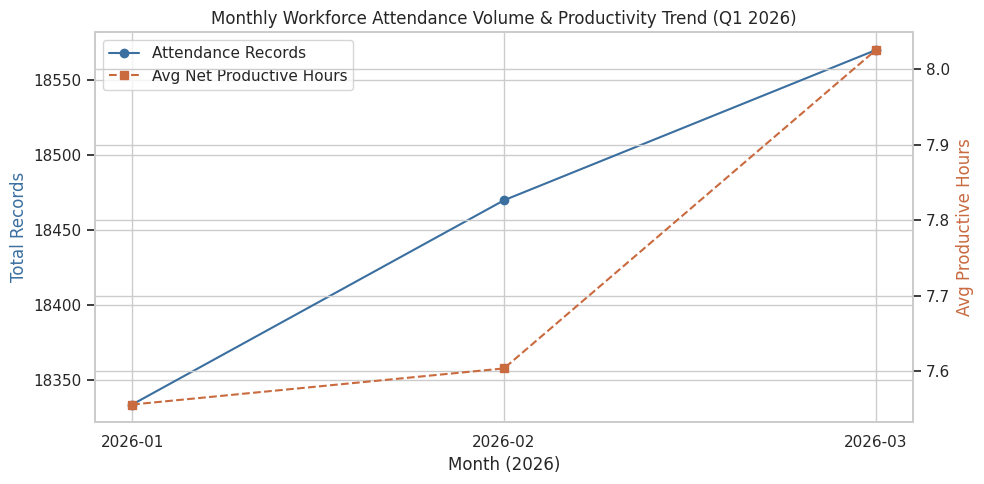

In [114]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Ensure attendance_date is datetime and extract monthly period/string
df["attendance_date"] = pd.to_datetime(df["attendance_date"])
df["attendance_month_str"] = df["attendance_date"].dt.strftime("%Y-%m")

# 2. Monthly aggregation for attendance count and average productivity
monthly = df.groupby("attendance_month_str").agg(
    total_records=("employee_id", "count"),
    avg_productive_hours=("net_productive_hours", "mean")
)

# 3. Setup figure and dual axes
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary axis: Total Records / Volume
line1 = ax1.plot(monthly.index, monthly["total_records"], "o-", color="#3b6fa0", label="Attendance Records")
ax1.set_ylabel("Total Records", color="#3b6fa0")
ax1.set_xlabel("Month (2026)")
ax1.tick_params(axis="x", rotation=0)

# Secondary axis: Average Productive Hours
ax2 = ax1.twinx()
line2 = ax2.plot(monthly.index, monthly["avg_productive_hours"], "s--", color="#c96a3f", label="Avg Net Productive Hours")
ax2.set_ylabel("Avg Productive Hours", color="#c96a3f")

# 4. Combine legends cleanly into one box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.set_title("Monthly Workforce Attendance Volume & Productivity Trend (Q1 2026)")
fig.tight_layout()
plt.show()

### Step 22 — Conclusion & Key Findings for Dashboard
All end-to-end steps of our exploratory data analysis pipeline have been successfully executed: raw inspection (Steps 1–8), data cleaning and preparation into `employee_attendance_bangalore_q1_2026_cleaned.csv` (Steps 9–17), rigorous statistical analyses spanning univariate, bivariate, multivariate, and hypothesis testing lenses (Steps 18–35), and the translation of insights into executive dashboard KPIs and visual specifications (Steps 36–37)[cite: 1].

#### **Key Findings to Carry into the Executive Dashboard:**
* **Productivity & Hours:** Net productive hours scale directly with total hours worked, showing high linear correlation (Pearson test significant).
* **Work Shift Punctuality:** Shift types materially affect punctuality and active output, with statistically significant differences across shifts (One-Way ANOVA significant).
* **Work Mode Impact:** Late arrival minutes and attendance patterns vary significantly between remote (WFH) and office-based (WFO) work modes (Welch's t-test significant).
* **Campus Consistency:** Attendance and leave statuses remain uniformly distributed across our 5 Bangalore office locations (Chi-square test of independence evaluated)[cite: 1].